# Lab 3: Deep Learning

The early part of this notebook follows the spirit of [Deep Learning with PyTorch: A 60 Minute Blitz](https://docs.pytorch.org/tutorials/beginner/deep_learning_60min_blitz), introducing tensors, automatic differentiation, and the basic `nn.Module` structure through practical examples. This notebook is self-contained, so you do not need to read the Blitz tutorial before starting. It is, however, a useful companion or follow-up if you want another pass over the same ideas.

## What this notebook does

You begin with automatic differentiation and gradient descent, then build a single neuron. You extend it into a fully connected layer and a small multilayer perceptron (MLP), implementing the main components from scratch and checking them against PyTorch. You then train your model on Fashion-MNIST, replace it with a convolutional neural network (CNN), and finish with a short experiment on how batch size and learning rate affect training.

## Learning objectives

By the end of the notebook, you should be able to:

- explain how a fully connected layer combines matrix multiplication with a bias;
- implement `Linear` and `ReLU` from scratch and verify them against PyTorch;
- train an MLP and a CNN on Fashion-MNIST and interpret their training and test accuracy;
- explain why a CNN is better suited to image data than a plain MLP;
- predict qualitatively how batch size and learning rate affect training behaviour.

## How to work through the notebook

Cells labelled **Task N** are where you write code. Each task is followed by a check cell that compares your implementation with PyTorch or measures its accuracy on real data. If the check reports a match or shows reasonable accuracy, continue to the next task. A `NotImplementedError` means that the cell is waiting for you to complete its code.

Run all cells from top to bottom. Later cells usually depend on definitions and results from earlier ones, so skipping ahead may produce confusing errors.


In [ ]:
# =============================================================================
# Google Colab setup
#
# On Colab: uncomment the two pip lines below and run this cell once.
# Locally (`uv sync`): skip this cell, the environment is already pinned.
#
# The first line installs the CPU-only PyTorch build, the same one pinned in
# uv.lock. It uses --index-url, which replaces PyPI for that command, so
# matplotlib is installed separately on the second line.
#
# numpy and pillow arrive as torchvision dependencies and need no explicit pin.
# The lab trains on CPU in a few minutes; no GPU runtime is needed.
# =============================================================================

# !pip install -q --index-url https://download.pytorch.org/whl/cpu \
#     torch==2.12.0 torchvision==0.27.0
# !pip install -q "matplotlib>=3.10"


## Imports

In [2]:
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

torch.manual_seed(7)


## Deep Learning As Optimization

Before any code, the big picture.

A deep learning model is a function with many adjustable numbers — its **parameters**, often written collectively as $\theta$. Training the model means choosing values for $\theta$ so that the model maps inputs to outputs in a useful way.

We turn "useful" into a single number with a **loss function** $L(\theta)$, which measures how wrong the model is on the training data. Training is then an optimization problem:

$$
\theta^{\star} = \arg\min_{\theta} \, L(\theta).
$$

The loss is typically a complicated, high-dimensional function — easily millions of parameters in a moderate model — so we cannot solve this in closed form. Instead, we minimize it iteratively by **gradient descent**. At each step we compute the gradient $\nabla_{\theta} L(\theta)$, which points in the direction the loss grows fastest, and take a small step in the opposite direction:

$$
\theta \leftarrow \theta - \eta \, \nabla_{\theta} L(\theta).
$$

Here $\eta$ is the **learning rate**, a small positive number that controls the step size. Repeating this update many times is what "training a neural network" means in practice.

The next section introduces **autograd**, the PyTorch machinery that computes $\nabla_{\theta} L$ for us so we never have to derive it by hand.

When something later "trains" or "does not train", the diagnostic question is always: *is the loss going down?*

## A Quick Introduction To Torch Autograd

Gradient descent needs $\partial L / \partial w$ for every parameter $w$. **Autograd** is PyTorch's machinery for computing those gradients automatically. During the forward pass, PyTorch records every operation on tensors that have `requires_grad=True`. When we call `loss.backward()`, autograd walks backward through that recorded graph and fills in `.grad` on each such tensor.

Here is a deliberately tiny example with `x = 2`, `w = 3`, and `y = 5`:

```python
y_pred = x * w            # 2 * 3 = 6
loss = (y - y_pred) ** 2  # (5 - 6)**2 = 1
loss.backward()
```

The red values in the figure below show the gradients that autograd computes. For this example, $\partial \mathrm{loss} / \partial w = 4$, so increasing `w` would increase the loss; gradient descent would therefore *decrease* `w`.

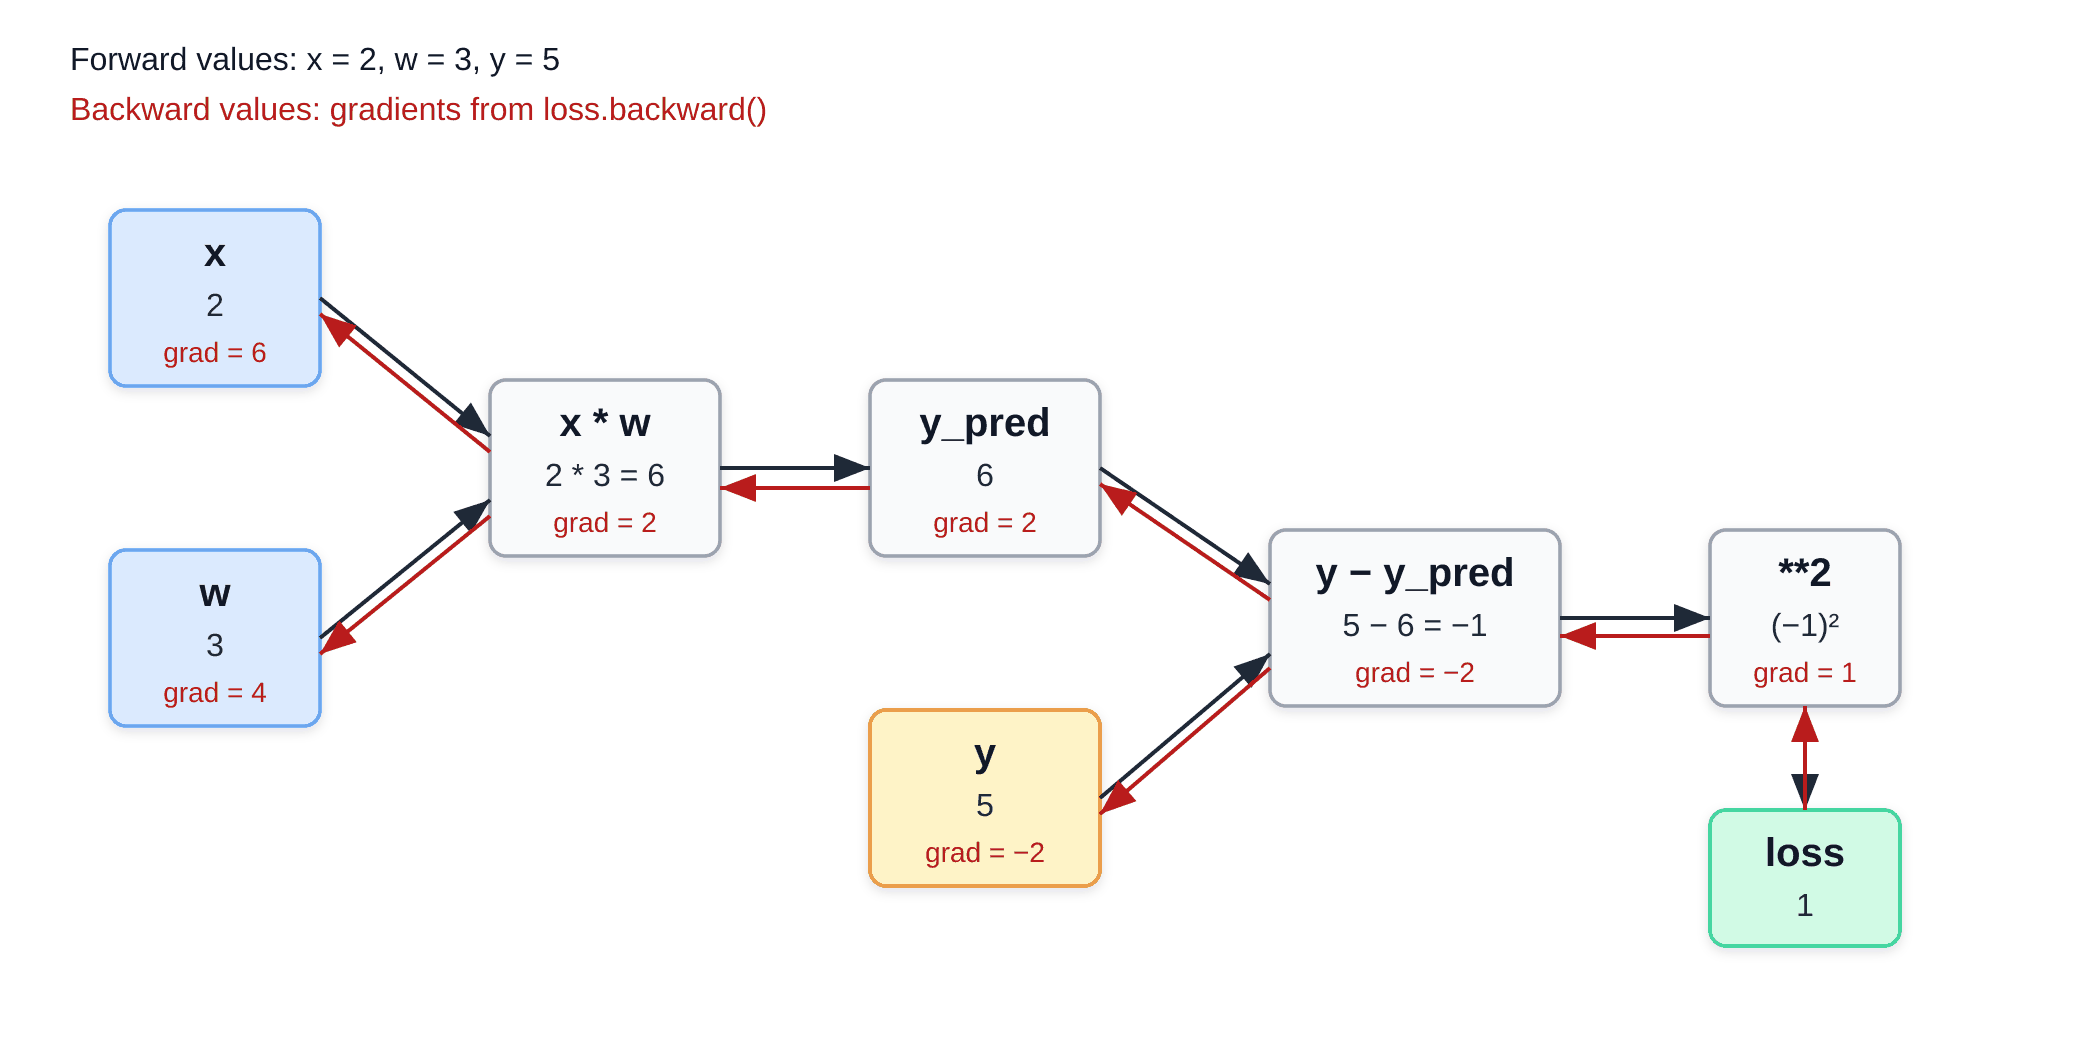

In [ ]:
x = torch.tensor(2.0)
y = torch.tensor(5.0)
w = torch.tensor(3.0, requires_grad=True)

y_pred = x * w
loss = (y - y_pred) ** 2

loss.backward()

print("y_pred:", y_pred.item())
print("loss:", loss.item())
print("gradient for w:", w.grad.item())

## A Single Neuron

The autograd example above is already a very small neuron-like computation: it has one input `x` and one weight `w`, so the prediction is just `y_pred = x * w`. That example did not include a bias term or a ReLU activation yet.

Now we extend the idea to a more typical neuron with several inputs, several weights, a bias, and later a non-linear activation.

One of the most basic blocks in deep learning are Multi-layer Perceptrons (MLPs). 
The core of an MLP are neurons. 

A single neuron receives several input numbers. Each input gets multiplied by a weight, and then we add a bias.

For three inputs, the weighted sum is:

$$
z = w_1x_1 + w_2x_2 + w_3x_3 + b
$$

Writing every term separately is useful at first, but neural networks quickly become too large for that notation. Instead, we put the inputs in one vector and the weights in another vector:

$$
x = [x_1, x_2, x_3]
$$

$$
w = [w_1, w_2, w_3]
$$

Then the weighted sum is a dot product plus bias:

$$
z = x \cdot w + b
$$

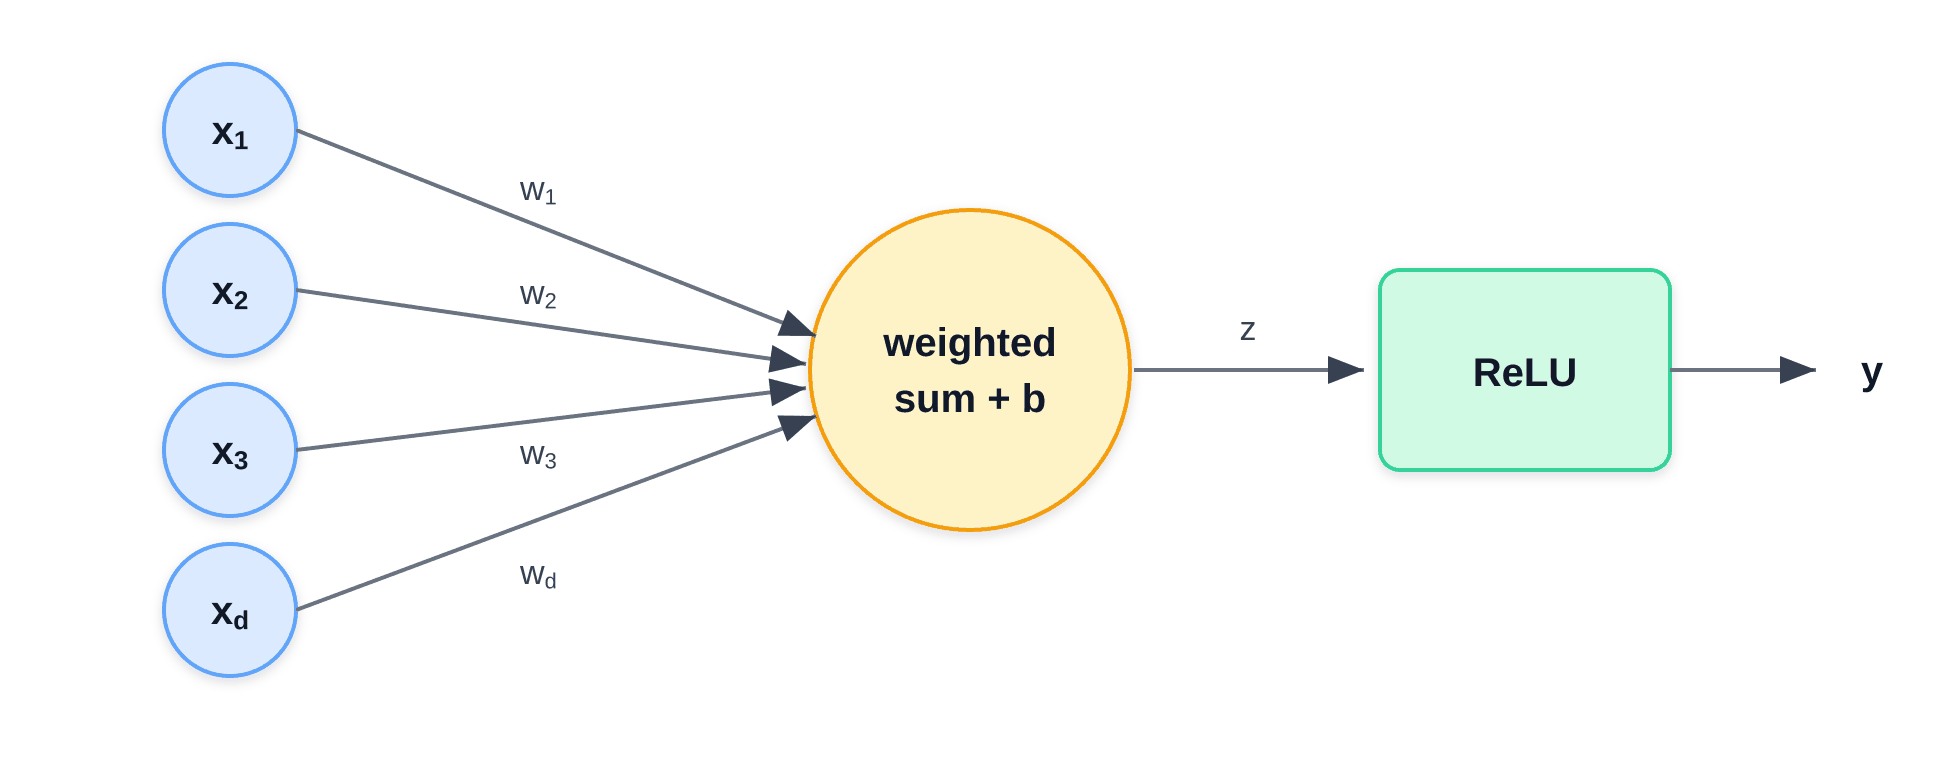


## Task 0: Tensors, Shapes, And One Neuron

A tensor is a rectangular collection of numbers. The number of axes is called the tensor rank or number of dimensions. In PyTorch, `.shape` tells us the size along each axis.

- A 1D tensor is a vector.
- A 2D tensor is a matrix.
- A 3D tensor can be understood as a stack of matrices.

Run the first cell and inspect the printed shapes. Then use the `@` operator in the second cell to compute one neuron as a vector dot product plus bias. For two 1D tensors, `@` computes the dot product.

In [12]:
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
])
tensor_3d = torch.tensor([
    [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]],
    [[7.0, 8.0, 9.0], [10.0, 11.0, 12.0]],
])

print("1D tensor / vector:")
print(vector)
print("shape:", vector.shape)

print("\n2D tensor / matrix:")
print(matrix)
print("shape:", matrix.shape)

print("\n3D tensor / stack of matrices:")
print(tensor_3d)
print("shape:", tensor_3d.shape)

1D tensor / vector:
tensor([1., 2., 3.])
shape: torch.Size([3])

2D tensor / matrix:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape: torch.Size([2, 3])

3D tensor / stack of matrices:
tensor([[[ 1.,  2.,  3.],
         [ 4.,  5.,  6.]],

        [[ 7.,  8.,  9.],
         [10., 11., 12.]]])
shape: torch.Size([2, 2, 3])


In [3]:
x = torch.tensor([2.0, -1.0, 0.5])
w = torch.tensor([0.25, 0.75, -0.5])
b = torch.tensor(0.1)

print("x shape:", x.shape)
print("w shape:", w.shape)
print("b shape:", b.shape)

# Same calculation, written out term by term.
z_written_out = x[0] * w[0] + x[1] * w[1] + x[2] * w[2] + b

# TODO: use the @ operator to compute the dot product, then add b.
z_with_at = ...

# torch.matmul is an explicit function for the same operation.
z_with_matmul = torch.matmul(x, w) + b

print("written out:", z_written_out)
print("using @:", z_with_at)
print("using torch.matmul:", z_with_matmul)

assert torch.allclose(z_with_at, z_written_out)
assert torch.allclose(z_with_at, z_with_matmul)

written out: tensor(-0.4000)
using @: Ellipsis


TypeError: allclose(): argument 'input' (position 1) must be Tensor, not ellipsis

## Why Add A Non-Linear Activation?

After the weighted sum, a neuron usually applies an activation function. In this notebook we use ReLU:

$$
\mathrm{ReLU}(z) = \max(0, z)
$$

ReLU leaves positive values unchanged and turns negative values into zero. 
The idea is that a weighted sum followed by a non-linear activation can [approximate any function](https://en.wikipedia.org/wiki/Universal_approximation_theorem). 
Thus, in contrast to standard Machine Learning models, Deep Learning is more powerful due to this non-linearity. 

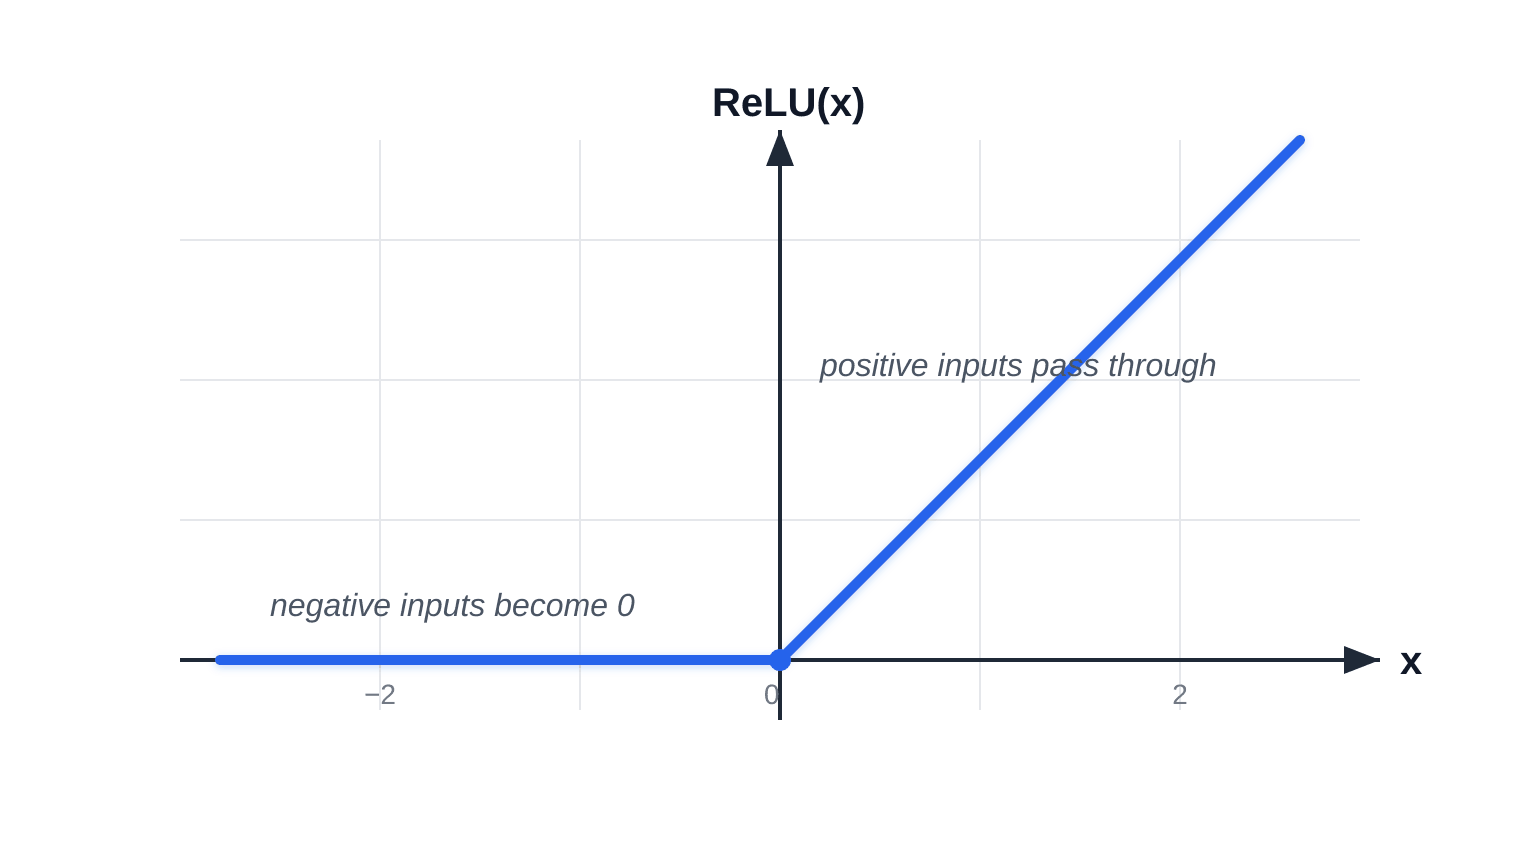


In [4]:
z_values = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])
relu_values = torch.relu(z_values)

print("z values:   ", z_values)
print("ReLU(z):    ", relu_values)

z values:    tensor([-2.0000, -0.5000,  0.0000,  0.5000,  2.0000])
ReLU(z):     tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])


## A Fully Connected Layer

A fully connected layer contains many neurons. Every input is connected to every output neuron.

If we stack several inputs together as rows of a matrix $X$, the whole layer becomes one matrix multiplication:

$$
Y = X W^T + b
$$

PyTorch stores the weights of `nn.Linear(in_features, out_features)` with shape `(out_features, in_features)`, so the forward pass uses `weight.T` when we write it manually.

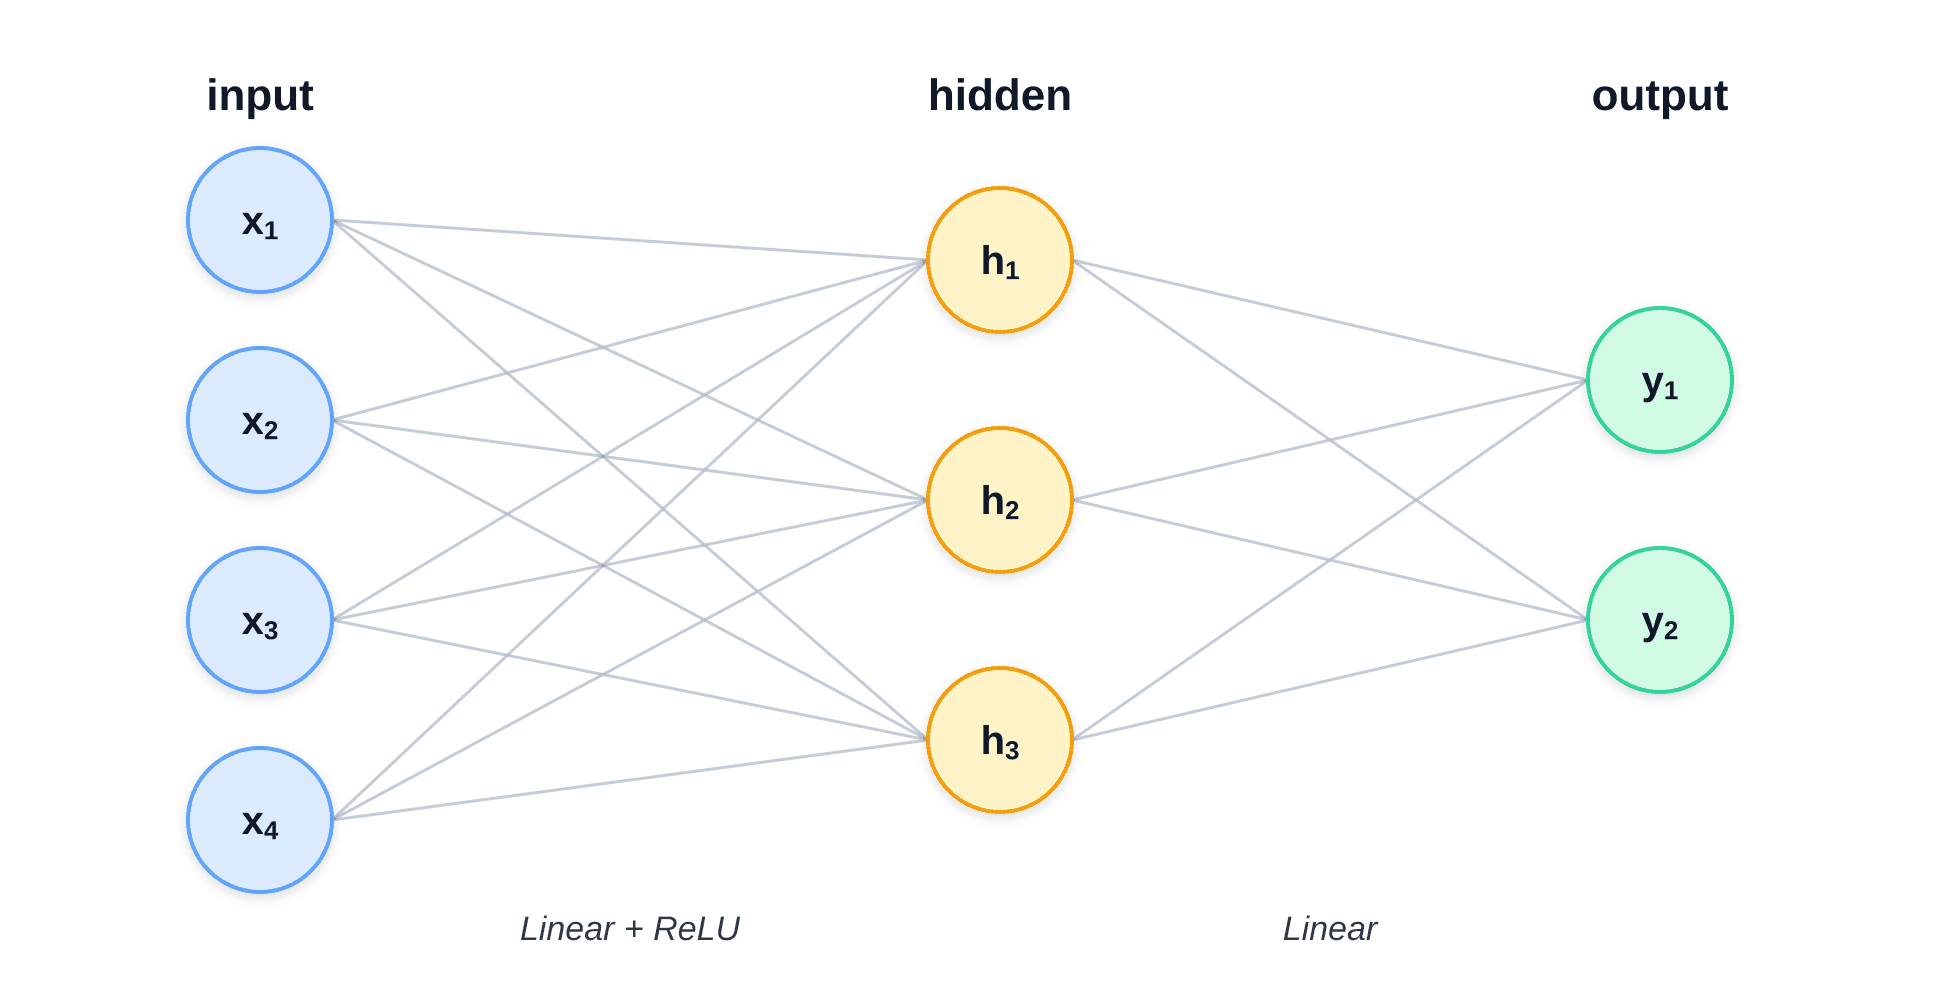

What would happen if we left out the non-linear activations? The whole network would collapse into a chain of matrix multiplications,

$$
Y = X \, W_1 \, W_2 \, \cdots \, W_n,
$$

and matrix multiplication is associative, so this equals

$$
Y = X (W_1 \, W_2 \, \cdots \, W_n) = X W
$$

for one combined matrix $W$. An $n$-layer MLP without activations is therefore exactly as expressive as a single linear layer — depth only buys us extra expressiveness because of the non-linearity in between.

## Matrix Multiplication Shapes

Suppose we have four examples, each with three input features. Arranged as rows of a matrix, they have shape `(4, 3)`. A layer with five output neurons has five rows of weights, each row containing three weights — shape `(5, 3)`.

Matrix multiplication contracts the *inner* dimensions, so the layer computes

$$
\underbrace{X}_{(4,\,3)} \;\; \underbrace{W^T}_{(3,\,5)} \;=\; \underbrace{Y}_{(4,\,5)}.
$$

The inner `3`s line up and disappear; the outer dimensions stay. That is why we transpose `W`: PyTorch stores the matrix as `(out, in)` because each row is the weight vector of one output neuron, which is easy to read, but the matrix product itself needs the `in`-dimension in the middle.

In [5]:
num_examples = 4
in_features = 3
out_features = 5

X = torch.randn(num_examples, in_features)
W = torch.randn(out_features, in_features)
b = torch.randn(out_features)

Y = X @ W.T + b

print("X shape:", X.shape)
print("W shape:", W.shape)
print("b shape:", b.shape)
print("Y shape:", Y.shape)

X shape: torch.Size([4, 3])
W shape: torch.Size([5, 3])
b shape: torch.Size([5])
Y shape: torch.Size([4, 5])


## Creating our MLPs

The next cell is an example of a tiny MLP. Most building blocks are already pre-implemented in the `nn` package (short for neural network) of PyTorch. Later, we will create our own MLP from scratch.

The MLP below takes 3 inputs and produces a single output value. One forward pass through it computes

$$
y = W_2 \, \mathrm{ReLU}(W_1 x + b_1) + b_2
$$

where $W_1$ has shape $(4, 3)$ and $W_2$ has shape $(1, 4)$, matching the two `nn.Linear` layers below.

In [ ]:
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(3, 4)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x

model = TinyMLP()
x = torch.randn(3)
output = model(x)

print(output)
print(output.shape)

tensor([-0.0157,  0.1114], grad_fn=<ViewBackward0>)
torch.Size([2])


### Batches

Earlier we already stacked four examples as rows of one matrix so that the whole layer could be computed in a single matrix multiplication. That grouping has a name: a **batch**, and its size is usually written $B$. So an input with $B$ examples of three features each has shape `(B, 3)`.

Working in batches is useful for two reasons:

- **Speed.** One big matrix multiplication runs in parallel inside PyTorch's tensor backend; running the model on each example in a Python loop would be much slower.
- **Smoother gradients.** Averaging the gradient over a small batch reduces noise compared to using one example at a time, while staying far cheaper than using the whole dataset.

In [14]:
# Pass a single example (1D input of length 3).
x_single = torch.randn(3)
print("single input shape: ", x_single.shape)
print("single output shape:", model(x_single).shape)

# Pass a batch of 8 examples (2D input of shape (8, 3)).
x_batch = torch.randn(8, 3)
print("batch input shape:  ", x_batch.shape)
print("batch output shape: ", model(x_batch).shape)

## Task 1: Implement `OurLinear`

Implement the forward pass of a fully connected layer.

Requirements:

- Store `weight` as an `nn.Parameter` with shape `(out_features, in_features)`.
- Store `bias` as an `nn.Parameter` with shape `(out_features,)`.
- In `forward`, compute the output given the formula above.

For this exercise we initialize the parameters with `torch.rand`, which draws from uniform $[0, 1)$. That is **not** a good initialization in practice — real PyTorch layers use a more careful scheme so that activations neither blow up nor shrink to zero across many layers — but it does not matter for this task: the correctness check below copies the parameters from a real `nn.Linear` into your layer before comparing outputs.


In [ ]:
class OurLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        weight_values = None  # TODO: create a tensor of shape (out_features, in_features) using torch.rand.
        bias_values = None    # TODO: create a tensor of shape (out_features,) using torch.rand.

        self.weight = None    # TODO: wrap weight_values in an nn.Parameter.
        self.bias = None      # TODO: if bias=True, wrap bias_values in an nn.Parameter; otherwise leave self.bias as None.


    def forward(self, x):
        # TODO: implement the linear layer forward pass.
        # Hint: PyTorch stores linear weights as (out_features, in_features),
        # so transposing weight gives the (in_features, out_features) shape
        # you need for the matrix multiplication x @ weight.T.
        raise NotImplementedError("Implement OurLinear.forward")

## Check `OurLinear` Against `nn.Linear`

This check creates a PyTorch layer and your layer, copies the same weight and bias into both, and verifies that both layers produce the same output for the same input.

In [ ]:
torch.manual_seed(3)

in_features = 4
out_features = 6
x = torch.randn(8, in_features)

torch_linear = nn.Linear(in_features, out_features)
our_linear = OurLinear(in_features, out_features)

with torch.no_grad():
    our_linear.weight.copy_(torch_linear.weight)
    our_linear.bias.copy_(torch_linear.bias)

torch_output = torch_linear(x) # NOTE: torch_linear.forward(x) is the same as torch_linear(x). That is true for all nn.Module subclasses: calling the instance directly will invoke the forward method.
our_output = our_linear(x)

print("Maximum absolute difference:", (torch_output - our_output).abs().max().item())
assert torch.allclose(torch_output, our_output)
print("OurLinear matches nn.Linear.")

## Task 2: Implement `OurReLU`

Implement ReLU from its mathematical definition:

$$
\mathrm{ReLU}(x) = \max(0, x)
$$

The operation should work element by element for tensors of any shape.

**Expected output** of the check cell once `OurReLU` is correct: the PyTorch tensor and your tensor should be identical, and the final line should print `OurReLU matches nn.ReLU.`

In [ ]:
class OurReLU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # TODO: implement ReLU.
        # Hint: torch.clamp, torch.maximum, or boolean masking can all work.
        raise NotImplementedError("Implement OurReLU.forward")

## Check `OurReLU` Against `nn.ReLU`

In [ ]:
x = torch.tensor([
    [-2.0, -0.5, 0.0],
    [0.2, 1.5, 4.0],
])

torch_relu = nn.ReLU()
our_relu = OurReLU()

torch_output = torch_relu(x)
our_output = our_relu(x)

print("PyTorch output:\n", torch_output)
print("Our output:\n", our_output)
assert torch.equal(torch_output, our_output)
print("OurReLU matches nn.ReLU.")

## Task 3: Replace PyTorch Layers In A Small MLP

Now use your layers inside a small network. The model below has the same structure as the earlier `TinyMLP`, but uses `OurLinear` and `OurReLU` instead of PyTorch's built-in layers. The point is to confirm that a network built from your own components computes exactly the same function as the PyTorch version, once both use the same weights.

**Expected output** of the check cell: the maximum absolute difference between the two outputs is `0.0`, and the final line prints `The full model using OurLinear and OurReLU matches the PyTorch version.`

In [ ]:
class OurTinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = OurLinear(3, 4)
        self.activation = OurReLU()
        self.layer2 = OurLinear(4, 2)

    def forward(self, x):
        x = self.layer1(x) 
        x = self.activation(x)
        x = self.layer2(x)
        return x

our_model = OurTinyMLP()
print(our_model)

## Check The Whole MLP

As before, we copy the exact same parameters into both models and compare their outputs.

In [ ]:
torch.manual_seed(11)

torch_model = TinyMLP()
our_model = OurTinyMLP()
x = torch.randn(10, 3)

with torch.no_grad():
    our_model.layer1.weight.copy_(torch_model.layer1.weight)
    our_model.layer1.bias.copy_(torch_model.layer1.bias)
    our_model.layer2.weight.copy_(torch_model.layer2.weight)
    our_model.layer2.bias.copy_(torch_model.layer2.bias)

torch_output = torch_model(x)
our_output = our_model(x)

print("Maximum absolute difference:", (torch_output - our_output).abs().max().item())
assert torch.allclose(torch_output, our_output)
print("The full model using OurLinear and OurReLU matches the PyTorch version.")

## Autograd Still Works

Because `OurLinear` uses `nn.Parameter` and ordinary PyTorch tensor operations, autograd can still compute gradients through it.

In [ ]:
x = torch.randn(5, 3)
target = torch.randn(5, 2)

model = OurTinyMLP()
prediction = model(x)
loss = ((prediction - target) ** 2).mean()
loss.backward()

print("loss:", loss.item())
print("gradient shape for first layer weights:", model.layer1.weight.grad.shape)
print("gradient shape for second layer bias:", model.layer2.bias.grad.shape)

## Task 4: Train An MLP On Fashion-MNIST

Fashion-MNIST is a small image classification dataset. Each example is a grayscale image of a clothing item, and the target is one of ten classes such as shirt, sneaker, bag, or coat.

Conceptually, an image is a tensor with shape:

$$
\mathrm{height} \times \mathrm{width} \times \mathrm{color\ channels}
$$

For an RGB image, the color channels would usually be red, green, and blue. Fashion-MNIST is grayscale, so it has only one color channel. In PyTorch image datasets, the channel dimension is usually stored first, so one Fashion-MNIST image has shape `(1, 28, 28)`, meaning `(channels, height, width)`.

An MLP expects one vector per example. Therefore, before passing an image into an MLP, we flatten it: every pixel value gets its own fixed input index. For Fashion-MNIST, this gives `1 * 28 * 28 = 784` input numbers. This also means that a plain MLP relies on fixed-size inputs: if the image size changes, the number of input features changes too.

The dataset is split into a training set and a test set. We use the training set to update the model weights. We keep the test set separate and only use it after training to estimate how well the model works on images it has not learned from directly. This helps us detect overfitting, where a model performs well on the training examples but poorly on new examples.

**What to expect**: after three epochs you should see training accuracy climb and the per-epoch loss decreasing each epoch. If the loss is flat or growing, something is wrong — most likely the learning rate or the gradient-zeroing step.

In [ ]:
data_dir = Path("data")

# ToTensor converts image values from integers in [0, 255]
# to floating point values in [0.0, 1.0].
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=True,
    download=True,
    transform=transform,
)

# NOTE: We want to prevent the model to generalize to new data, so we have different data for training and testing. 
test_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=transform,
)

class_names = train_dataset.classes
print(class_names)
print("number of training examples:", len(train_dataset))
print("number of test examples:", len(test_dataset))

## Inspect A Few Training Images

Before building the model, it helps to look at the data. The next cell shows a small grid of Fashion-MNIST images with their class labels.

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(8, 5))

for ax, index in zip(axes.flat, range(15)):
    image, label = train_dataset[index]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

## One Image Through The Model

Before training, let us inspect one image and pass it through an MLP. The dataset gives us one image with shape `(1, 28, 28)`. The model expects a batch, so we add a batch dimension with `unsqueeze(0)`, giving shape `(1, 1, 28, 28)`.

Inside the model, `nn.Flatten()` turns each image into a vector of length `784`. The output has length `10`, one score for each class.

In [ ]:
class FashionMNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.layers(x)
        return x


model = FashionMNISTMLP()

print("model parameters:", sum(p.numel() for p in model.parameters()))

image, label = train_dataset[0]
print("single image shape:", image.shape)
print("label:", label, class_names[label])

plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("off")
plt.show()

image_batch = image.unsqueeze(0)
scores = model(image_batch)

print("batch shape:", image_batch.shape)
print("model output shape:", scores.shape)
print("scores:", scores)

## Data Loading

Training one image at a time would be slow and noisy. Instead, we use batches. A batch is a group of examples processed together. For images in PyTorch, a batch has shape:

$$
B \times C \times H \times W
$$

where `B` is batch size, `C` is the number of channels, `H` is height, and `W` is width. For Fashion-MNIST with batch size `64`, the image tensor has shape `(64, 1, 28, 28)`.

The `ToTensor()` transform already normalizes the raw pixel values from integers in `0..255` to floating point values in `0..1`. This is not strictly necessary for every model, but it often makes training easier because the numbers passed into the network are smaller and more consistent.

In [ ]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_loader))
print("image batch shape:", images.shape)
print("label batch shape:", labels.shape)
print("min pixel value:", images.min().item())
print("max pixel value:", images.max().item())

## SGD And The Training Loop

SGD stands for stochastic gradient descent. It is gradient descent applied to small batches of data instead of the full dataset at once. For each batch, we:

1. Run the model forward to get class scores.
2. Compute the loss.
3. Use `loss.backward()` to compute gradients.
4. Use `optimizer.step()` to update the model parameters.

For classification with ten classes, we use `nn.CrossEntropyLoss()`. The model outputs one score per class. PyTorch turns these scores into probabilities internally and then penalizes the probability assigned to the correct class.

For one training example, cross entropy is:

$$
L = -\log(p_{\mathrm{correct}})
$$

where $p_{\mathrm{correct}}$ is the probability that the model assigns to the true class. If the model predicts the correct class with probability close to `1`, then `-log(1) = 0`, so the loss is close to zero. If the model assigns a small probability to the correct class, the loss becomes large.

**Before running the next cell**, predict how the loss should change across the three epochs. Read the output as it appears: if the loss is not going *down* each epoch, training is broken and continuing to run will not help.

**Common pitfall**: forgetting `optimizer.zero_grad()`. PyTorch *accumulates* gradients into `.grad` by default, so without zeroing, every batch sees the sum of all earlier gradients and the model trains poorly — usually the loss starts going up rather than down. This is one of the most common bugs in handwritten training loops.

In [ ]:
torch.manual_seed(7)

# 1. Initialize the model.
model = FashionMNISTMLP()

# CrossEntropyLoss is the standard loss for multi-class classification.
loss_fn = nn.CrossEntropyLoss()

# 2. Initialize the optimizer.
# SGD is the update rule that changes the weights using the gradients.
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        predictions = model(images)
        loss = loss_fn(predictions, labels)

        # PyTorch accumulates gradients by default.
        # We clear old gradients before computing gradients for this batch.
        optimizer.zero_grad()

        loss.backward()

        # optimizer.step() updates the weights using the gradients.
        optimizer.step()

        batch_size_actual = images.shape[0]
        total_loss += loss.item() * batch_size_actual
        correct += (predictions.argmax(dim=1) == labels).sum().item()
        total += batch_size_actual

    avg_loss = total_loss / total
    accuracy = correct / total
    print(f"epoch {epoch + 1}: loss = {avg_loss:.4f}, accuracy = {accuracy:.3f}")

## Evaluate On The Test Set

The test set contains images the model did not train on. This gives us a better estimate of how well the model learned the task, instead of only memorizing the training examples.

A useful sanity check is to compare the test accuracy you see here to the *final-epoch training accuracy* printed above. If they are close, the model generalizes well. If training accuracy is much higher than test accuracy, the model is overfitting — it has memorized training-set details that do not transfer to new images.

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        predictions = model(images)
        correct += (predictions.argmax(dim=1) == labels).sum().item()
        total += labels.shape[0]

print(f"test accuracy: {correct / total:.3f}")

## Task 5: Convolutional Neural Networks

An MLP treats a flattened image as one long vector. This works, but it ignores the fact that nearby pixels are usually related. A pixel and its neighbor often belong to the same edge, texture, or object part.

A convolutional neural network, or CNN, builds this assumption into the model. Instead of connecting every pixel to every hidden unit, a convolutional layer applies small filters to local image patches. This is an **inductive bias**: an assumption built into the model that helps it learn image data more efficiently.

Without padding, a convolution usually makes the image smaller because the filter cannot be centered on the border pixels. Padding adds extra border pixels, typically zeros, so we can control how much the width and height shrink.

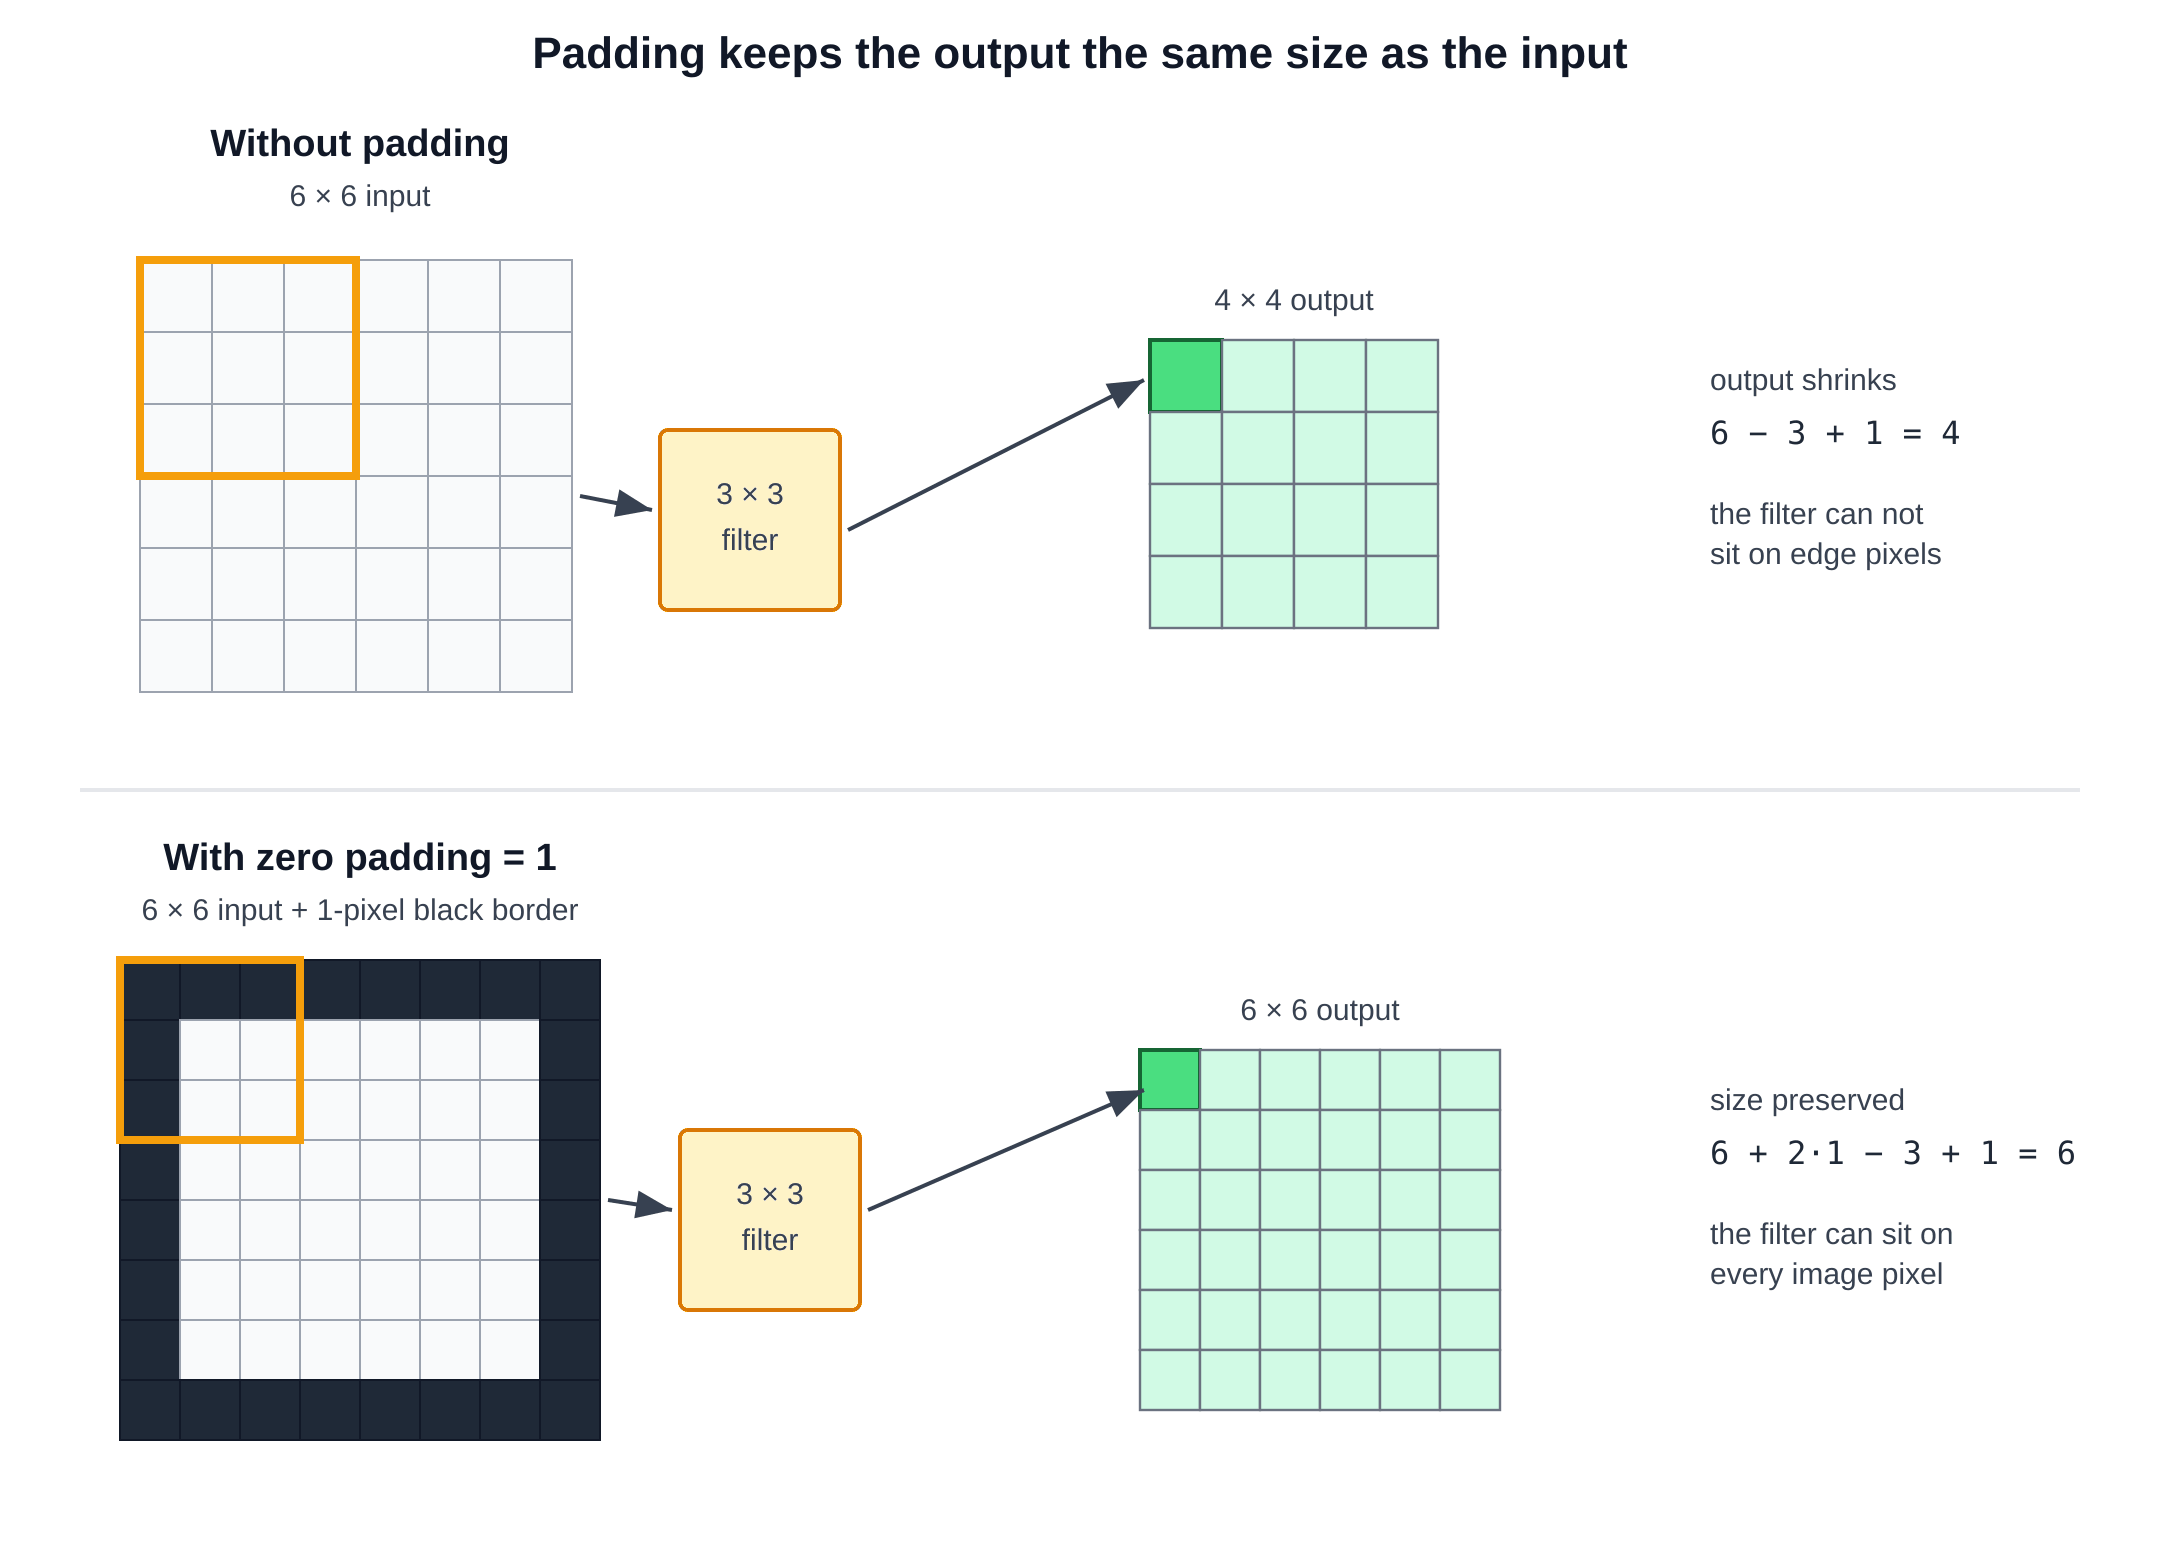

**Predict before you run the CNN below**: do you expect a CNN to do *better*, *worse*, or *about the same* as the MLP on Fashion-MNIST? Write your guess down (or just commit to it mentally) before training — we will compare at the end of this section.

## Width, Height, Channels, And Padding

For image tensors in PyTorch, one batch has shape `B x C x H x W`: batch size, channels, height, width. A convolutional layer uses this structure directly.

For one output channel and one input channel, a convolution computes a weighted sum over a small local patch:

$$
Y[i, j] = b + \sum_{u=0}^{K-1} \sum_{v=0}^{K-1} W[u, v] \, X[i + u, j + v]
$$

Here, `K` is the kernel size. The same weights `W` are reused at every spatial position. With multiple input channels, the layer also sums over channels. With multiple output channels, the layer learns multiple filters.

For stride `1`, the output width or height is:

$$
\mathrm{out} = \mathrm{in} + 2 \cdot \mathrm{padding} - \mathrm{kernel\ size} + 1
$$

This is why a `3 x 3` filter without padding maps width `6` to width `4`, while padding `1` keeps width `6`.

The PyTorch layer is `nn.Conv2d`. A typical call is:

```python
nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
```

- `in_channels=1`: Fashion-MNIST images are grayscale.
- `out_channels=16`: the layer learns 16 different filters, producing 16 output channels.
- `kernel_size=3`: each filter looks at a `3 x 3` local patch.
- `stride=1`: the filter moves one pixel at a time.
- `padding=1`: add a one-pixel border around the image before applying the filter.

The important point for now: convolutional layers usually change the channel dimension, and padding and pooling can change width and height.

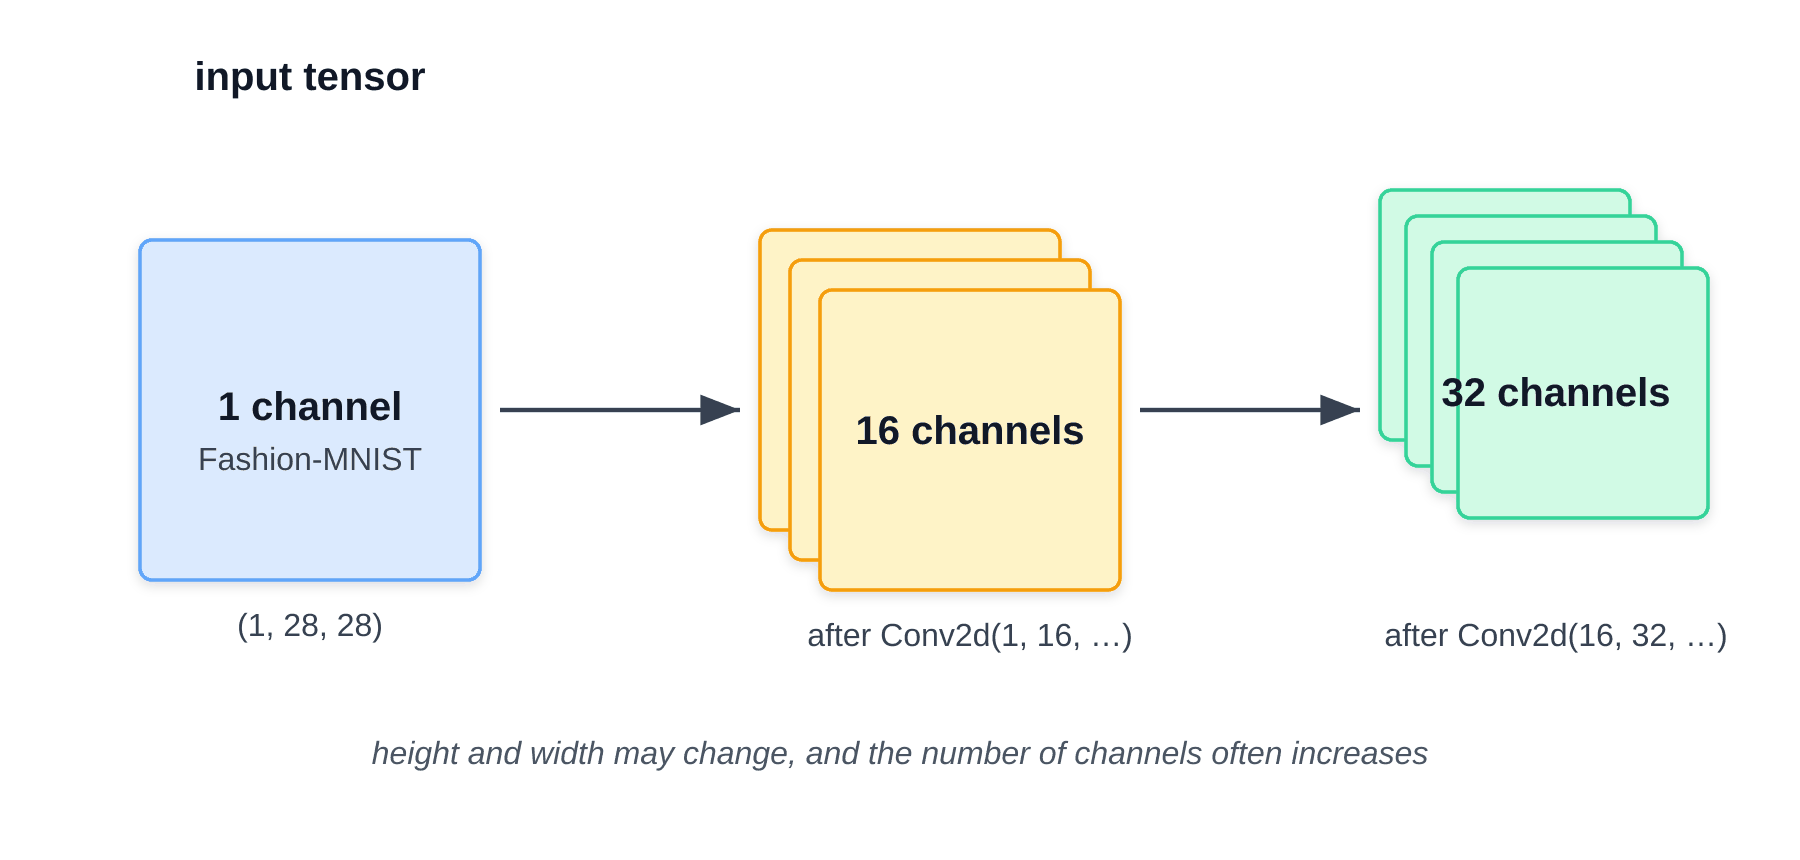

## Max Pooling And The Final MLP

CNNs often use pooling layers. We will use `nn.MaxPool2d(2)`. You do not need the details here; the key idea is that max pooling shrinks the image over time by summarizing small regions. With `MaxPool2d(2)`, width and height are roughly halved.

CNNs typically end with an MLP. The convolution and pooling layers extract spatial features. Then we flatten the final feature maps into a vector and use linear layers to produce class scores.

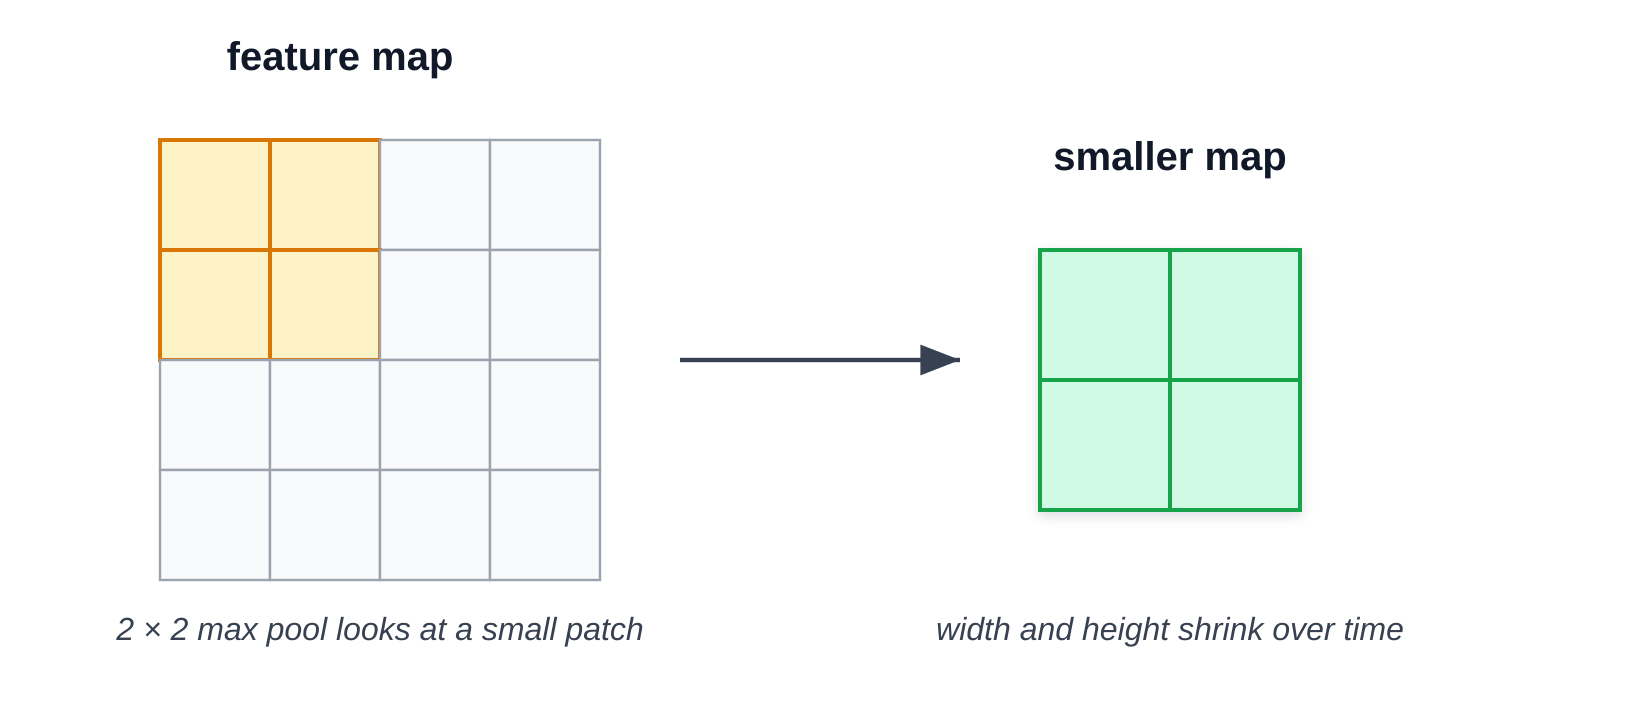

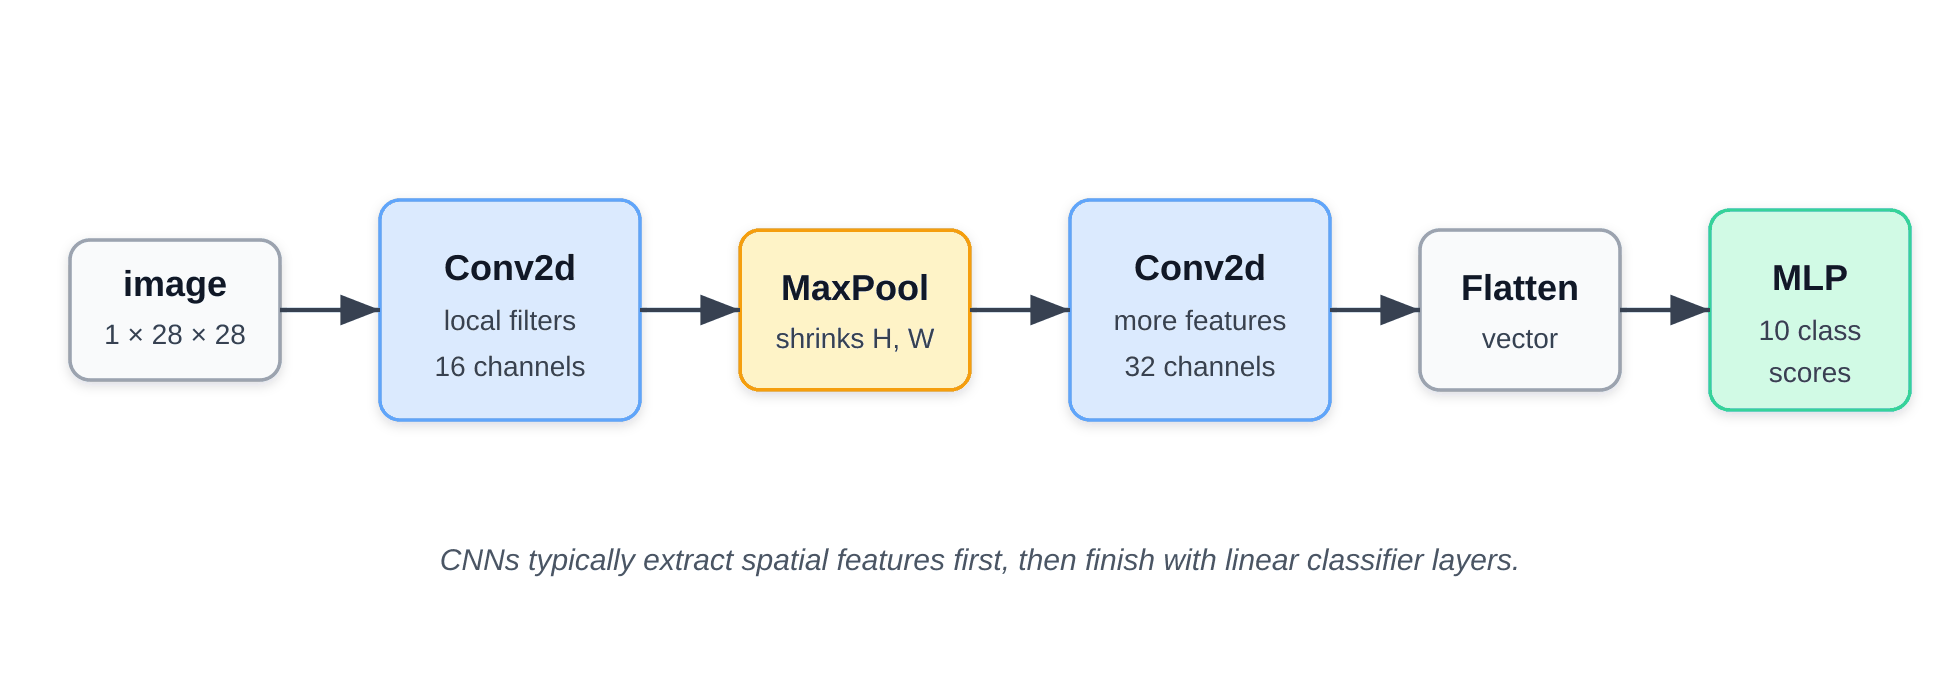

In [ ]:
class FashionMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # NOTE: nn.Sequential is a convenient way to chain together multiple layers. It will call each layer in order when we call the forward method of the Sequential.
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn = FashionMNISTCNN()

print("cnn parameters:", sum(p.numel() for p in cnn.parameters()))
images, labels = next(iter(train_loader))
scores = cnn(images)

print("input batch shape:", images.shape)
print("after CNN feature extractor:", cnn.features(images).shape)
print("output scores shape:", scores.shape)

## Train The CNN

The training pipeline is the same as for the MLP. We initialize a model, initialize an optimizer, clear gradients for each batch, run the forward pass, compute the loss, run the backward pass, and call `optimizer.step()`.

In [ ]:
torch.manual_seed(7)

# 1. Initialize the CNN model.
cnn = FashionMNISTCNN()

loss_fn = nn.CrossEntropyLoss()

# 2. Initialize the optimizer.
optimizer = torch.optim.SGD(cnn.parameters(), lr=0.1)

num_epochs = 5

for epoch in range(num_epochs):
    cnn.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        predictions = cnn(images)
        loss = loss_fn(predictions, labels)

        # Gradients accumulate in PyTorch, so we clear the old ones first.
        optimizer.zero_grad()

        loss.backward()

        # Update CNN filter weights and classifier weights.
        optimizer.step()

        batch_size_actual = images.shape[0]
        total_loss += loss.item() * batch_size_actual
        correct += (predictions.argmax(dim=1) == labels).sum().item()
        total += batch_size_actual

    avg_loss = total_loss / total
    accuracy = correct / total
    print(f"epoch {epoch + 1}: loss = {avg_loss:.4f}, accuracy = {accuracy:.3f}")

## Evaluate The CNN

We evaluate the CNN on the same held-out test set as before.

Compare the number below to the MLP test accuracy from the previous section, and compare the
two parameter counts printed earlier. The CNN reaches several percentage points higher while
using almost exactly the same number of parameters, so whatever it gains, it does not gain by
being a bigger model.

Was your earlier prediction correct? Reflection 1 below asks you to explain *why* it wins.


In [ ]:
cnn.eval()
correct = 0
total = 0
# NOTE: accuracy is the ratio of correct predictions to total examples. 

with torch.no_grad():
    for images, labels in test_loader:
        predictions = cnn(images)
        correct += (predictions.argmax(dim=1) == labels).sum().item()
        total += labels.shape[0]

print(f"CNN test accuracy: {correct / total:.3f}")

## Reflection 1: Why convolution helps

Why does the CNN suit image data better than the MLP, considering local receptive fields, weight sharing, and translation equivariance?

*Write your answer in the cell below.*


_Your answer here._


## Task 6: Hyperparameter Evaluation

Model parameters are learned by gradient descent. Hyperparameters are choices we make before training. Two important hyperparameters are batch size and learning rate.

- Batch size controls how many examples are used for one gradient update. Smaller batches give noisier updates. Larger batches give smoother updates but use more memory.
- Learning rate controls how large each optimizer step is. If it is too small, training can be slow. If it is too large, training can become unstable.

**Before you fill in the values**, sketch on paper what you expect each curve to look like. Do you expect very small learning rates to help or hurt? Very large ones? Should the curve be monotonic in batch size, or have a sweet spot? Run the experiment and check whether your prediction held up.

In this task, we change one hyperparameter at a time and measure both test accuracy and how long training takes. To keep the experiment fast enough for a lab notebook, we train each model for one epoch on a fixed subset of the training set. The comparison is not a final benchmark; it is a controlled experiment to see how these choices affect training.

In [ ]:
def train_and_evaluate_mlp(batch_size, learning_rate, num_epochs=1):
    """Train a fresh MLP and return (test accuracy, seconds spent training)."""
    torch.manual_seed(7)

    # Use fixed subsets so the hyperparameter experiment runs quickly.
    train_subset = Subset(train_dataset, range(20_000))
    test_subset = Subset(test_dataset, range(2_000))

    train_loader_hp = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    test_loader_hp = DataLoader(test_subset, batch_size=256, shuffle=False)

    model = FashionMNISTMLP()
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    # Time the training loop only, not the evaluation pass. Every configuration
    # sees the same 10 000 examples, so the difference is the cost of the updates.
    start = time.perf_counter()

    for epoch in range(num_epochs):
        model.train()
        for images, labels in train_loader_hp:
            predictions = model(images)
            loss = loss_fn(predictions, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    train_seconds = time.perf_counter() - start

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader_hp:
            predictions = model(images)
            correct += (predictions.argmax(dim=1) == labels).sum().item()
            total += labels.shape[0]

    return correct / total, train_seconds


## Evaluate Batch Size And Learning Rate

For the batch-size experiment, we keep the learning rate fixed. For the learning-rate experiment, we keep the batch size fixed. This makes the plots easier to interpret because only one choice changes at a time.

In [ ]:
# TODO: pick a few batch sizes to try. Reasonable values lie roughly between
# 8 and 512. Powers of two like 8, 32, 128, 512 give a useful spread.
batch_sizes = []

# TODO: pick a few learning rates to try. Reasonable values lie roughly between
# 1e-3 and 1.0. The plot below uses a log scale, so spacing them on a log grid
# (e.g. 0.001, 0.01, 0.1, 1.0) makes the result easier to read.
learning_rates = []

fixed_learning_rate = 0.1
fixed_batch_size = 64

batch_size_accuracies = []
batch_size_times = []
for batch_size in batch_sizes:
    accuracy, seconds = train_and_evaluate_mlp(
        batch_size=batch_size,
        learning_rate=fixed_learning_rate,
    )
    batch_size_accuracies.append(accuracy)
    batch_size_times.append(seconds)
    print(f"batch size {batch_size}: test accuracy = {accuracy:.3f}, "
          f"training time = {seconds:.1f}s")

learning_rate_accuracies = []
for learning_rate in learning_rates:
    accuracy, seconds = train_and_evaluate_mlp(
        batch_size=fixed_batch_size,
        learning_rate=learning_rate,
    )
    learning_rate_accuracies.append(accuracy)
    print(f"learning rate {learning_rate}: test accuracy = {accuracy:.3f}, "
          f"training time = {seconds:.1f}s")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(batch_sizes, batch_size_accuracies, marker="o")
axes[0].set_title("Accuracy vs batch size")
axes[0].set_xlabel("batch size")
axes[0].set_ylabel("test accuracy")
axes[0].set_xticks(batch_sizes)
axes[0].grid(True, alpha=0.3)

axes[1].plot(learning_rates, learning_rate_accuracies, marker="o")
axes[1].set_title("Accuracy vs learning rate")
axes[1].set_xlabel("learning rate")
axes[1].set_ylabel("test accuracy")
axes[1].set_xscale("log")
axes[1].grid(True, alpha=0.3)

# Put both accuracy panels on the same scale so they can be compared directly.
all_accuracies = batch_size_accuracies + learning_rate_accuracies
if all_accuracies:
    low, high = min(all_accuracies), max(all_accuracies)
    pad = 0.05 * (high - low) if high > low else 0.05
    axes[0].set_ylim(low - pad, high + pad)
    axes[1].set_ylim(low - pad, high + pad)

axes[2].plot(batch_sizes, batch_size_times, marker="o", color="tab:orange")
axes[2].set_title("Training time vs batch size")
axes[2].set_xlabel("batch size")
axes[2].set_ylabel("seconds per epoch")
axes[2].set_xticks(batch_sizes)
axes[2].grid(True, alpha=0.3)

fig.suptitle("Hyperparameter evaluation on Fashion-MNIST")
plt.tight_layout()
plt.show()


## Reflection 2: Batch-size trade-off

Based on your two plots, what trade-off between test accuracy and training time must you make when choosing a batch size?

*Write your answer in the cell below.*


_Your answer here._


## Wrap-Up

In this notebook you:

1. Saw a one-line example of `autograd` computing a gradient.
2. Implemented `OurLinear` and `OurReLU` from scratch and verified them against PyTorch.
3. Trained an MLP on Fashion-MNIST and reached roughly 86% test accuracy.
4. Replaced the MLP with a CNN and gained roughly three points of test accuracy, using the same training loop, the same number of epochs, and almost exactly the same number of parameters. The gain comes from the architecture, not from extra capacity.
5. Measured how batch size and learning rate affect a model's final accuracy, and how batch size trades accuracy against training time.

### What we deliberately skipped

- **Weight initialization.** We used `torch.rand` in `OurLinear` for simplicity. Real PyTorch layers use Kaiming uniform, which keeps the variance of activations roughly constant across layers and avoids the vanishing/exploding signal problem in deep networks.
- **Learning-rate schedules.** We held the learning rate fixed; production training usually decays it over time (`torch.optim.lr_scheduler`).
- **Regularization beyond cross-entropy.** Data augmentation, weight decay, batch normalization, and residual connections are all standard in larger CNNs.

If you want to keep going, the official [PyTorch tutorials](https://docs.pytorch.org/tutorials/) is a good next step. 